## 3.Model

In [15]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error

from sktime.forecasting.var import VAR
from sktime.utils.plotting import plot_series

In [2]:
df = pd.read_csv('../data/cleared-combine-21-23.csv', index_col='time', parse_dates=True)
df.head()

,temp,dwpt,rhum,prcp,wdir,wspd,pres,coco,771826-ML,717696-ML,...,767351-ML,717819-ML,717823-ML,767367-ML,717825-ML,717827-ML,771808-ML,771767-ML,772011-ML,772024-ML
time,,,,,,,,,,,,,,,,,,,,,
2021-01-01 00:00:00,17.8,0.0,30.0,0.0,350.0,24.1,1013.0,2.0,690.0,846.0,...,1391.0,1147.0,1072.0,1407.0,1142.0,1107.0,2530.0,3291.0,675.0,743.0
2021-01-01 01:00:00,16.7,-0.1,32.0,0.0,340.0,24.1,1013.1,2.0,793.0,880.0,...,1537.0,1248.0,1151.0,1445.0,1190.0,1140.0,2655.0,3487.0,733.0,801.0
2021-01-01 02:00:00,16.1,-0.6,32.0,0.0,330.0,25.9,1013.9,2.0,463.0,609.0,...,1164.0,873.0,808.0,1037.0,855.0,823.0,2238.0,2938.0,449.0,541.0
2021-01-01 03:00:00,16.1,-1.0,31.0,0.0,330.0,22.3,1014.0,2.0,347.0,403.0,...,862.0,585.0,541.0,642.0,544.0,551.0,1813.0,2506.0,327.0,408.0
2021-01-01 04:00:00,15.0,-1.6,32.0,0.0,320.0,20.5,1013.9,1.0,388.0,473.0,...,753.0,501.0,503.0,561.0,476.0,448.0,1711.0,2557.0,286.0,454.0


In [3]:
df.index.freq = 'h'

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 26280 entries, 2021-01-01 00:00:00 to 2023-12-31 23:00:00
Freq: h
Columns: 113 entries, temp to 772024-ML
dtypes: float64(113)
memory usage: 22.9 MB


## VAR

In [70]:
# monthly
df_m = df.resample('ME').mean().diff().diff().dropna()

In [71]:
train, test = train_test_split(df_m, test_size = 0.25, shuffle = False)

In [72]:
X_train = train.iloc[:, :8]
y_train = train.iloc[:, 8:]
y_test = test.iloc[:, 8:]

In [73]:
model = VAR(maxlags=12, verbose=True)

In [74]:
model.fit(y_train, X_train)

VAR(maxlags=12, verbose=True)

In [75]:
model.get_test_params()

[{'maxlags': 3}, {'trend': 'ctt'}]

In [76]:
preds = model.predict(test.index)

preds

,771826-ML,717696-ML,718219-ML,717701-ML,717703-ML,718227-ML,717706-ML,717709-ML,716632-ML,771845-ML,...,767351-ML,717819-ML,717823-ML,767367-ML,717825-ML,717827-ML,771808-ML,771767-ML,772011-ML,772024-ML
time,,,,,,,,,,,,,,,,,,,,,
2023-04-30,21.696380,1.267079,16.253882,71.552275,39.813056,32.022272,40.616224,4.828844,48.943408,-61.356661,...,-66.002330,84.020508,-24.903856,69.171634,14.283098,113.300167,-206.477479,-201.877021,-43.168847,-125.056956
2023-05-31,-39.011037,-54.474584,-62.549342,-96.083264,-7.482914,-73.710981,-60.049094,-53.469317,-131.240472,-22.434681,...,-100.657255,-255.661242,31.334432,-141.188614,10.357226,-212.451920,-128.978257,-211.928196,-1.234448,-20.919849
2023-06-30,62.748920,34.974626,14.935144,47.707629,-49.769812,-12.954227,-28.082333,12.926434,13.851473,33.673584,...,-20.546623,35.506836,-78.349290,-41.514154,-173.579966,143.857405,149.044063,169.433169,-4.486437,4.079150
2023-07-31,-26.205338,4.139202,34.403818,18.643299,55.778867,83.583935,85.871734,21.234284,98.970684,-52.805937,...,82.528710,167.602516,5.638255,147.959877,292.630190,18.123882,-72.225099,-7.336829,-2.735757,-1.658935
2023-08-31,-62.930140,-96.772509,-129.633002,-157.638302,-112.405967,-149.835376,-124.705534,-85.479274,-213.368043,-90.026674,...,-127.889245,-276.457924,-22.798585,-211.736645,-224.715737,-209.995099,80.270306,20.584859,-14.890572,-41.916647
2023-09-30,63.286160,89.145002,101.333802,154.861823,27.028564,113.338676,81.759600,65.159083,171.168440,139.294695,...,-53.677959,25.529005,-98.478953,-26.210902,-37.907442,107.504113,154.473752,142.735622,10.259886,59.002727
2023-10-31,-18.900828,-52.253398,-41.319601,-91.024981,21.439394,0.514091,14.420812,-20.599562,-15.900964,-105.372030,...,111.169013,171.763627,72.148172,172.340583,117.658240,107.031047,-137.116243,-92.417706,16.863001,-5.125400
2023-11-30,2.286543,10.999278,-16.612347,1.943312,-35.698728,-56.555829,-55.581806,3.325829,-91.864199,86.385180,...,-188.765673,-333.601066,-46.318020,-258.338858,-40.594602,-214.728467,132.085706,18.077305,-27.661891,-20.647525
2023-12-31,13.764112,22.389942,52.862127,67.696180,22.951425,72.482435,58.249595,17.242525,140.377097,17.857408,...,158.942870,329.844251,9.915994,209.585974,-5.983589,266.439084,-37.729413,67.018092,41.577158,73.567140


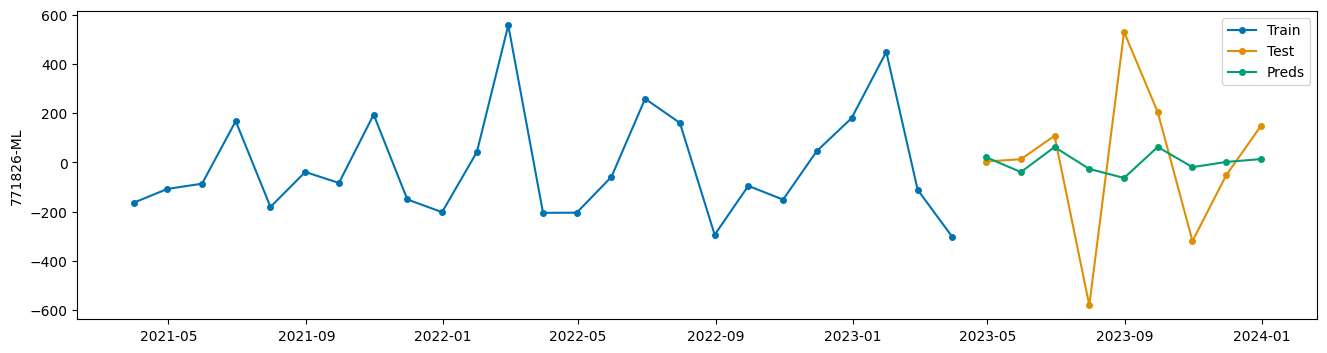

In [77]:
plot_series(y_train['771826-ML'], y_test['771826-ML'], preds['771826-ML'], labels= ['Train', 'Test', 'Preds']);

In [78]:
root_mean_squared_error(y_test['771826-ML'], preds['771826-ML'])

297.5101158485232

In [53]:
# weekly
df_w = df.resample('W').mean()
train, test = train_test_split(df_w, test_size = 0.25, shuffle = False)
X_train = train.iloc[:, :8]
y_train = train.iloc[:, 8:]
y_test = test.iloc[:, 8:]

In [54]:
model = VAR(maxlags=52, verbose=True)
model.fit(y_train, X_train)

VAR(maxlags=52, verbose=True)

In [55]:
preds = model.predict(test.index)

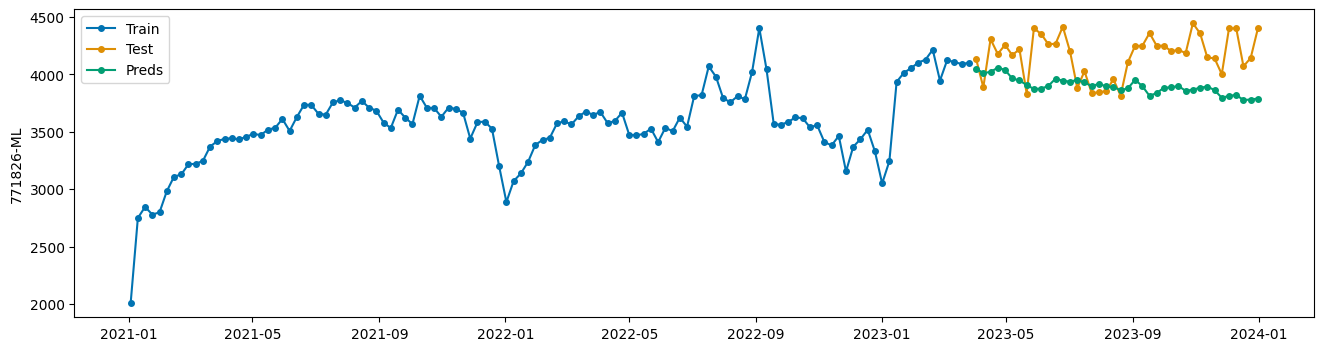

In [56]:
plot_series(y_train['771826-ML'], y_test['771826-ML'], preds['771826-ML'], labels= ['Train', 'Test', 'Preds']);

In [57]:
root_mean_squared_error(y_test['771826-ML'], preds['771826-ML'])

336.36190884216916

In [65]:
# daily
df_d = df.resample('d').mean()
train, test = train_test_split(df_d, test_size = 0.25, shuffle = False)
X_train = train.iloc[:, :8]
y_train = train.iloc[:, 8:]
y_test = test.iloc[:, 8:]

In [66]:
model = VAR(maxlags=30, verbose=True)
model.fit(y_train, X_train)

VAR(maxlags=30, verbose=True)

In [67]:
preds = model.predict(test.index)

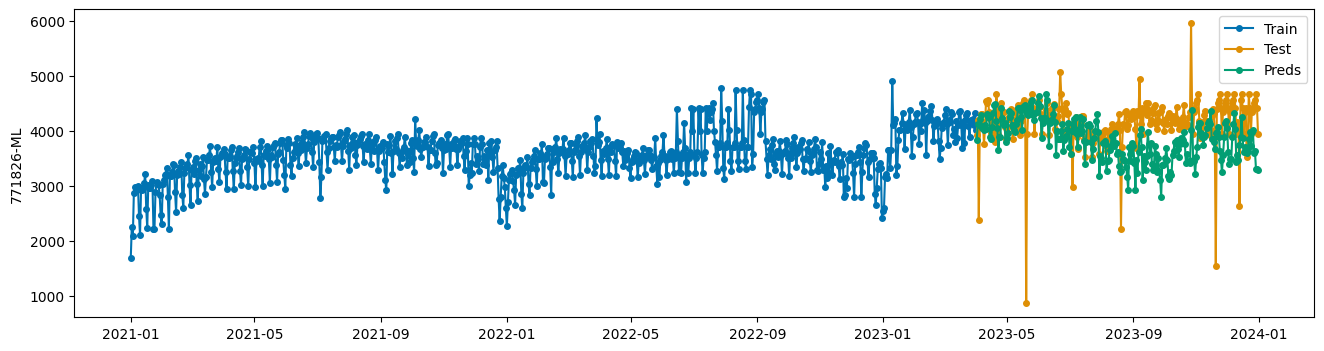

In [68]:
plot_series(y_train['771826-ML'], y_test['771826-ML'], preds['771826-ML'], labels= ['Train', 'Test', 'Preds']);

In [69]:
root_mean_squared_error(y_test['771826-ML'], preds['771826-ML'])

617.2129938265614

In [58]:
# hourly
train, test = train_test_split(df, test_size = 0.25, shuffle = False)
X_train = train.iloc[:, :8]
y_train = train.iloc[:, 8:]
y_test = test.iloc[:, 8:]

In [59]:
model = VAR(maxlags=24, verbose=True)
model.fit(y_train, X_train)

VAR(maxlags=24, verbose=True)

In [60]:
preds = model.predict(test.index)

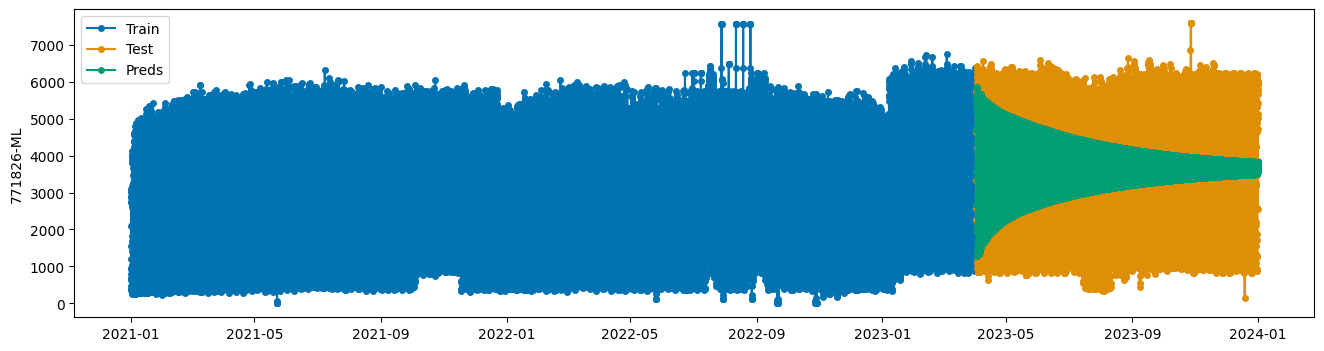

In [62]:
plot_series(y_train['771826-ML'], y_test['771826-ML'], preds['771826-ML'], labels= ['Train', 'Test', 'Preds']);

In [63]:
root_mean_squared_error(y_test['771826-ML'], preds['771826-ML'])

1572.5409348458963

In [64]:
root_mean_squared_error(y_test.iloc[:, -1], preds.iloc[:, -1])

1411.4989133333886